# Document Repacking Goldilocks: A Fresh, Comprehensive Search

Follow-up to `09_document_repacking.ipynb`, and a sibling to `11_chunking_goldilocks.ipynb`
/ `12_retriever_goldilocks.ipynb` / `13_query_transformation_goldilocks.ipynb` /
`14_reranking_goldilocks.ipynb`. Tests the paper's Document Repacking module (§3.6:
forward / reverse / sides ordering, motivated by Liu et al. 2024a's "lost in the middle"
finding) on top of this repo's actual best-known pipeline.

**A real wrinkle, flagged up front rather than discovered mid-notebook:** `14`'s winning
config keeps only **final_k=2** reranked chunks. Repacking is about *where in a longer
context* relevant information sits -- with 2 chunks, forward and reverse produce the
identical reorder, and "sides" collapses to the same thing too. There's nothing to repack
at `14`'s own winning depth. So this notebook doesn't just drop repacking on top of `14`'s
config; it deliberately tests repacking at final_k depths wide enough for ordering to
matter (reusing `14`'s own Phase 3 candidates), then asks the question `14` couldn't:
**does a wider context with good repacking ever beat `14`'s narrow final_k=2 cut?**

1. **`09` scored on 5 unlucky, non-fixed samples per strategy**, with judge failures
   silently dropped -- the same noise problem the earlier audits flagged.
2. **`09` froze chunking at 192t semantic chunks and the retriever at Dense MMR (k=8), with
   no reranking at all** -- none of which are this repo's actual best-known configs anymore.
3. **`09` never varied context width alongside repacking strategy.** Repacking's entire
   premise (from the paper's own citation of "lost in the middle") is that ordering matters
   more as context grows; `09` tested exactly one context size, so it could never observe
   that relationship even if it existed.

This notebook fixes what's fixable in a single sitting: (1)/(2) via the fixed 20-question
evaluation set with retried judge annotations, the same composite score `11`-`14` used, and
the actual `11`+`12`+`13`+`14` winning stack (chunking, hybrid+HyDE retrieval, Cohere 4-Pro
reranking) as the foundation; (3) via a three-phase search (repacking strategy -> final_k
sweep -> head-to-head against `14`'s narrow winner) that treats context width as its own
axis instead of a silent constant.


## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib rank-bm25 requests


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Imports & Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

load_dotenv()
openrouter_token = os.environ.get("OPENROUTER_TOKEN")

import sys


def _add_ragbench_lib_to_path():
    for candidate in (os.getcwd(), os.path.join(os.getcwd(), "delucion_dataset")):
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.chunking import count_tokens, get_sentences
from ragbench_lib.retrievers import HybridRetriever
from ragbench_lib.trace_eval import (
    annotate_response_for_metrics_with_retry,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)

print("✓ All imports successful")


/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset (fixed evaluation set)

Same fixed-sample mechanism as `11`-`14` -- `EVAL_SAMPLE_SIZE` questions chosen once, up
front, and reused for every config in every phase below.

In [3]:
DATASET_NAME = "delucionqa"
EVAL_SAMPLE_SIZE = 20

print("Loading dataset...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(EVAL_SAMPLE_SIZE + 10, 30))
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

eval_questions_df = docs_df.drop_duplicates(subset=["row_id"]).head(EVAL_SAMPLE_SIZE).reset_index(drop=True)
print(f"✓ Fixed evaluation set: {len(eval_questions_df)} unique questions (reused for every config below)")


Loading dataset...
✓ Loaded 90 documents from 30 unique questions
✓ Fixed evaluation set: 20 unique questions (reused for every config below)


## Step 4: Models

In [4]:
embedding_model = get_embedding_model(openrouter_token)
llm = get_generation_llm(openrouter_token)
query_llm = get_generation_llm(openrouter_token, temperature=0.7, max_tokens=256)
llama_judge = get_judge_llm(openrouter_token)
prompt = RAG_GENERATION_PROMPT

print("✓ Embedding model, generator, query-transform LLM, and judge configured")


✓ Embedding model, generator, query-transform LLM, and judge configured


## Step 5: Fixed Chunking + Retrieval + Query-Transformation + Reranking Foundation

Every layer below this notebook's own variable is frozen at its winning config:

- **Chunking**: sentence-level + metadata heading, 64-token target, 10% overlap (`11`)
- **Retriever**: hybrid (BM25 + dense), alpha=0.3, wide candidate pool (`12`)
- **Query transformation**: HyDE, one hypothetical document concatenated with the query,
  driving retrieval only (`13`)
- **Reranker**: Cohere Rerank 4-Pro over a candidate pool of 20 (`14`'s Phase 1/2 winner)

Repacking strategy and final_k (how many reranked chunks to keep, and in what order) are
this notebook's independent variables.

In [5]:
CHUNK_TARGET_TOKENS = 64
CHUNK_OVERLAP_FRACTION = 0.10
RETRIEVER_ALPHA = 0.3
CANDIDATE_K = 20  # 14's winning candidate pool width


def sentence_level_chunks(docs_df, target_tokens=64, overlap_fraction=0.1):
    documents = []
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        if not sentences:
            continue
        sent_tokens = [count_tokens(s) for s in sentences]
        n = len(sentences)
        i, chunk_idx = 0, 0
        while i < n:
            chunk_sents, chunk_tok_count, j = [], 0, i
            while j < n and (not chunk_sents or chunk_tok_count + sent_tokens[j] <= target_tokens):
                chunk_sents.append(sentences[j])
                chunk_tok_count += sent_tokens[j]
                j += 1
            chunk_text = " ".join(chunk_sents)
            documents.append(Document(
                page_content=chunk_text,
                metadata={
                    "chunk_id": f"{doc['doc_id']}_sent{chunk_idx}",
                    "row_id": doc["row_id"],
                    "tokens": count_tokens(chunk_text),
                },
            ))
            chunk_idx += 1
            overlap_count = int(len(chunk_sents) * overlap_fraction)
            step = max(len(chunk_sents) - overlap_count, 1)
            i += step
    return documents


def metadata_enhanced_chunks(docs_df, target_tokens=64, overlap_fraction=0.1):
    documents = sentence_level_chunks(docs_df, target_tokens=target_tokens, overlap_fraction=overlap_fraction)

    doc_id_to_heading = {}
    for _, doc in docs_df.iterrows():
        sentences = get_sentences(doc["text"])
        heading = sentences[0] if sentences else doc["text"][:80]
        doc_id_to_heading[doc["doc_id"]] = " ".join(heading.split()[:12])

    enhanced = []
    for d in documents:
        source_doc_id = d.metadata["chunk_id"].rsplit("_sent", 1)[0]
        heading = doc_id_to_heading.get(source_doc_id, "")
        new_text = f"[Context: {heading}]\n{d.page_content}"
        enhanced.append(Document(
            page_content=new_text,
            metadata={**d.metadata, "tokens": count_tokens(new_text)},
        ))
    return enhanced


def apply_hyde(query, llm, n_docs=1, concat_with_query=True):
    """Winning HyDE config from 13: 1 hypothetical doc, concatenated with the query,
    used to drive retrieval only."""
    pseudo_docs = []
    for _ in range(n_docs):
        p = f"""Write a comprehensive document that would answer this question:

'{query}'

The document should be detailed and informative, covering all aspects of the answer."""
        try:
            pseudo_docs.append(llm.invoke(p).content.strip())
        except Exception:
            pass
    if not pseudo_docs:
        return query
    combined = " ".join(pseudo_docs)
    return f"{query} {combined}" if concat_with_query else combined


class OpenRouterReranker:
    """Cross-encoder reranking via OpenRouter's dedicated /api/v1/rerank endpoint.
    Returns documents in descending relevance order, alongside their relevance scores,
    so repacking strategies below can reorder that ranked list on their own terms."""

    def __init__(self, model_name, api_key):
        self.model_name = model_name
        self.api_key = api_key
        self.endpoint = "https://openrouter.ai/api/v1/rerank"

    def rerank(self, query, documents, top_k):
        if not documents:
            return documents
        doc_texts = [d.page_content for d in documents]
        headers = {"Authorization": f"Bearer {self.api_key}", "Content-Type": "application/json"}
        payload = {"model": self.model_name, "query": query, "documents": doc_texts, "top_n": top_k}
        try:
            response = requests.post(self.endpoint, headers=headers, json=payload, timeout=30)
            response.raise_for_status()
            result = response.json()
            if "results" in result:
                ranked = sorted(result["results"], key=lambda r: r.get("relevance_score", 0), reverse=True)
                indices = [r["index"] for r in ranked[:top_k]]
                return [documents[i] for i in indices]
            return documents[:top_k]
        except Exception as e:
            print(f"    [DEBUG] rerank error ({self.model_name}): {str(e)[:60]}")
            return documents[:top_k]


print("Building fixed chunking foundation (sentence + metadata, 64t, 10% overlap)...")
documents = metadata_enhanced_chunks(docs_df, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION)
print(f"✓ Built {len(documents)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents]):.0f} tokens/chunk")

print(f"Building wide hybrid retriever foundation (alpha=0.3, k={CANDIDATE_K})...")
wide_retriever = HybridRetriever(documents, embedding_model, k=CANDIDATE_K, alpha=RETRIEVER_ALPHA,
                                  dataset_name=DATASET_NAME, config_name="repack_foundation")
print("✓ Wide hybrid retriever ready")

reranker = OpenRouterReranker("cohere/rerank-4-pro", openrouter_token)
print("✓ Cohere 4-Pro reranker ready (14's Phase 1/2 winning model)")


Building fixed chunking foundation (sentence + metadata, 64t, 10% overlap)...
✓ Built 456 chunks, avg 68 tokens/chunk
Building wide hybrid retriever foundation (alpha=0.3, k=20)...
✓ Wide hybrid retriever ready
✓ Cohere 4-Pro reranker ready (14's Phase 1/2 winning model)


## Step 6: Repacking Strategies

Straight from the paper's §3.6: `forward` keeps the reranker's own descending-relevance
order (the implicit default every prior notebook used without naming it); `reverse` flips
to ascending relevance, putting the *most* relevant chunk immediately before the question;
`sides` splits the ranked list, placing the top-ranked chunks at both the head and tail of
the context with lower-ranked chunks in the middle -- the arrangement Liu et al. (2024a)
found LLMs attend to best.

In [6]:
def repack_forward(reranked_docs):
    """Descending relevance (reranker's own order) -- most relevant first."""
    return list(reranked_docs)


def repack_reverse(reranked_docs):
    """Ascending relevance -- most relevant last, immediately before the question."""
    return list(reversed(reranked_docs))


def repack_sides(reranked_docs):
    """Most relevant at head and tail, least relevant in the middle."""
    n = len(reranked_docs)
    head, tail = [], []
    for i, doc in enumerate(reranked_docs):
        if i % 2 == 0:
            head.append(doc)
        else:
            tail.insert(0, doc)
    return head + tail


REPACKING_STRATEGIES = {
    "forward": repack_forward,
    "reverse": repack_reverse,
    "sides": repack_sides,
}

print("✓ Repacking strategies ready (forward, reverse, sides)")


✓ Repacking strategies ready (forward, reverse, sides)


## Step 7: Evaluation Runner

Every config runs the fixed 20-question set through: HyDE-transform the query -> retrieve
`CANDIDATE_K` hybrid-ranked candidates -> Cohere 4-Pro rerank against the original question,
keeping `final_k` -> apply the repacking strategy to reorder those `final_k` chunks ->
generate from the original question -> retry judge annotation up to 3x -> compute TRACe
metrics + the same composite score `11`-`14` used.

In [7]:
def evaluate_repacking_config(config_name, repack_fn, final_k, eval_questions_df, max_annotate_attempts=3):
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = prompt | llm | StrOutputParser()

    per_sample = []
    n_failed = 0
    for _, row in eval_questions_df.iterrows():
        original_question = row["question"]
        try:
            retrieval_query = apply_hyde(original_question, query_llm, n_docs=1, concat_with_query=True)
            candidates = wide_retriever.retrieve(retrieval_query)[:CANDIDATE_K]
            reranked_docs = reranker.rerank(original_question, candidates, top_k=final_k)
            repacked_docs = repack_fn(reranked_docs)
            retrieved_texts = [d.page_content for d in repacked_docs]

            response_text = rag_chain.invoke({"context": format_docs(repacked_docs), "question": original_question})

            annotation = annotate_response_for_metrics_with_retry(
                llama_judge, retrieved_texts, original_question, response_text, max_attempts=max_annotate_attempts
            )
            if annotation["success"]:
                per_sample.append({
                    "context_relevance": compute_context_relevance(retrieved_texts, annotation),
                    "utilization": compute_utilization(retrieved_texts, annotation),
                    "completeness": compute_completeness(annotation),
                    "adherence": compute_adherence(annotation),
                })
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

    result = {
        "config": config_name,
        "final_k": final_k,
        "n_eval": len(per_sample),
        "n_failed": n_failed,
        "context_relevance": np.mean([r["context_relevance"] for r in per_sample]) if per_sample else None,
        "utilization": np.mean([r["utilization"] for r in per_sample]) if per_sample else None,
        "completeness": np.mean([r["completeness"] for r in per_sample]) if per_sample else None,
        "adherence": np.mean([r["adherence"] for r in per_sample]) if per_sample else None,
    }
    if per_sample:
        result["composite"] = (
            0.35 * result["context_relevance"]
            + 0.15 * result["utilization"]
            + 0.15 * result["completeness"]
            + 0.35 * result["adherence"]
        )
    else:
        result["composite"] = None
    return result


print("✓ evaluate_repacking_config defined")


✓ evaluate_repacking_config defined


## Step 8: Phase 1 -- Repacking Strategy Comparison (final_k=6)

final_k=6 is one of `14`'s own Phase 3 candidates (composite 0.580 there, using the
reranker's implicit forward order) -- wide enough for forward/reverse/sides to actually
differ, unlike `14`'s winning final_k=2. Isolates **repacking strategy**, with context
width fixed.

In [8]:
FINAL_K_PHASE1 = 6

print("=" * 100)
print(f"PHASE 1: REPACKING STRATEGY COMPARISON (final_k={FINAL_K_PHASE1}), {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase1_results = []
for name, repack_fn in REPACKING_STRATEGIES.items():
    print(f"\n--- {name} ---")
    result = evaluate_repacking_config(f"p1_{name}", repack_fn, FINAL_K_PHASE1, eval_questions_df)
    phase1_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
              f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase1_df = pd.DataFrame(phase1_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 1 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase1_df)


PHASE 1: REPACKING STRATEGY COMPARISON (final_k=6), 20 fixed questions

--- forward ---
  CR=0.3876 Util=0.1645 Comp=0.4935 Adh=1.0000 Composite=0.5844  (failed 0/20)

--- reverse ---
  CR=0.4406 Util=0.2096 Comp=0.5487 Adh=1.0000 Composite=0.6180  (failed 0/20)

--- sides ---
  CR=0.3705 Util=0.1902 Comp=0.4860 Adh=1.0000 Composite=0.5811  (failed 0/20)

PHASE 1 RESULTS (ranked by composite score)


,config,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
1,p1_reverse,6,20,0,0.440575,0.209625,0.54871,1.0,0.617951
0,p1_forward,6,20,0,0.387620,0.164545,0.49353,1.0,0.584378
2,p1_sides,6,20,0,0.370520,0.190170,0.48595,1.0,0.581100


## Step 9: Phase 2 -- Does Repacking's Value Scale With Context Width?

Takes Phase 1's winning strategy and sweeps final_k, holding strategy fixed -- tests the
paper's own "lost in the middle" motivation for repacking directly: does ordering matter
more as more chunks get crammed into context, or does it stay flat regardless of width?

In [9]:
phase1_winner = phase1_df.iloc[0]["config"].replace("p1_", "")
repack_fn = REPACKING_STRATEGIES[phase1_winner]
print(f"Phase 1 winner: {phase1_winner} -- sweeping final_k next\n")

final_k_values = [4, 6, 8, 12]

print("=" * 100)
print(f"PHASE 2: FINAL_K SWEEP for '{phase1_winner}' repacking, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase2_results = []
for final_k in final_k_values:
    print(f"\n--- {phase1_winner} @ final_k={final_k} ---")
    result = evaluate_repacking_config(f"p2_{phase1_winner}_fk{final_k}", repack_fn, final_k, eval_questions_df)
    phase2_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase2_df = pd.DataFrame(phase2_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 2 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase2_df)


Phase 1 winner: reverse -- sweeping final_k next

PHASE 2: FINAL_K SWEEP for 'reverse' repacking, 20 fixed questions

--- reverse @ final_k=4 ---
  CR=0.5050 Adh=0.9000 Composite=0.6027  (failed 0/20)

--- reverse @ final_k=6 ---
  CR=0.3889 Adh=0.9000 Composite=0.5679  (failed 0/20)

--- reverse @ final_k=8 ---
  CR=0.3195 Adh=0.8500 Composite=0.5154  (failed 0/20)

--- reverse @ final_k=12 ---
  CR=0.2194 Adh=0.9000 Composite=0.5014  (failed 0/20)

PHASE 2 RESULTS (ranked by composite score)


,config,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
0,p2_reverse_fk4,4,20,0,0.504995,0.230765,0.509110,0.90,0.602730
1,p2_reverse_fk6,6,20,0,0.388935,0.192090,0.586345,0.90,0.567892
2,p2_reverse_fk8,8,20,0,0.319490,0.177265,0.530175,0.85,0.515437
3,p2_reverse_fk12,12,20,0,0.219420,0.118120,0.612250,0.90,0.501352


## Step 10: Phase 3 -- Wide-and-Repacked vs. `14`'s Narrow Winner

The question this whole notebook exists to answer: does *any* final_k + repacking
combination beat `14`'s raw final_k=2, no-repacking-needed winner (composite 0.709)? Runs
Phase 2's best config directly against a fresh final_k=2 measurement (using this notebook's
own pipeline, for an apples-to-apples comparison rather than citing `14`'s number
directly).

In [10]:
phase2_winner_config = phase2_df.iloc[0]["config"]
phase2_winner_final_k = int(phase2_df.iloc[0]["final_k"])
print(f"Phase 2 winner: {phase2_winner_config} (final_k={phase2_winner_final_k}) -- "
      f"comparing against a fresh final_k=2 baseline\n")

print("=" * 100)
print(f"PHASE 3: WIDE+REPACKED vs. NARROW (final_k=2), {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase3_results = []

print(f"\n--- {phase1_winner} @ final_k={phase2_winner_final_k} (Phase 2 winner) ---")
result = evaluate_repacking_config(f"p3_{phase1_winner}_fk{phase2_winner_final_k}", repack_fn, phase2_winner_final_k, eval_questions_df)
phase3_results.append(result)
if result["composite"] is not None:
    print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} Composite={result['composite']:.4f}")

print(f"\n--- final_k=2, no repacking needed (forward order, single ordering) ---")
result = evaluate_repacking_config("p3_narrow_fk2", repack_forward, 2, eval_questions_df)
phase3_results.append(result)
if result["composite"] is not None:
    print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} Composite={result['composite']:.4f}")

phase3_df = pd.DataFrame(phase3_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 3 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase3_df)


Phase 2 winner: p2_reverse_fk4 (final_k=4) -- comparing against a fresh final_k=2 baseline

PHASE 3: WIDE+REPACKED vs. NARROW (final_k=2), 20 fixed questions

--- reverse @ final_k=4 (Phase 2 winner) ---
  CR=0.4915 Adh=0.9500 Composite=0.6161

--- final_k=2, no repacking needed (forward order, single ordering) ---
  CR=0.6024 Adh=0.9000 Composite=0.6821

PHASE 3 RESULTS (ranked by composite score)


,config,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
1,p3_narrow_fk2,2,20,0,0.602360,0.388615,0.653335,0.90,0.682119
0,p3_reverse_fk4,4,20,0,0.491515,0.226480,0.517400,0.95,0.616112


## Step 11: Visualize the Search

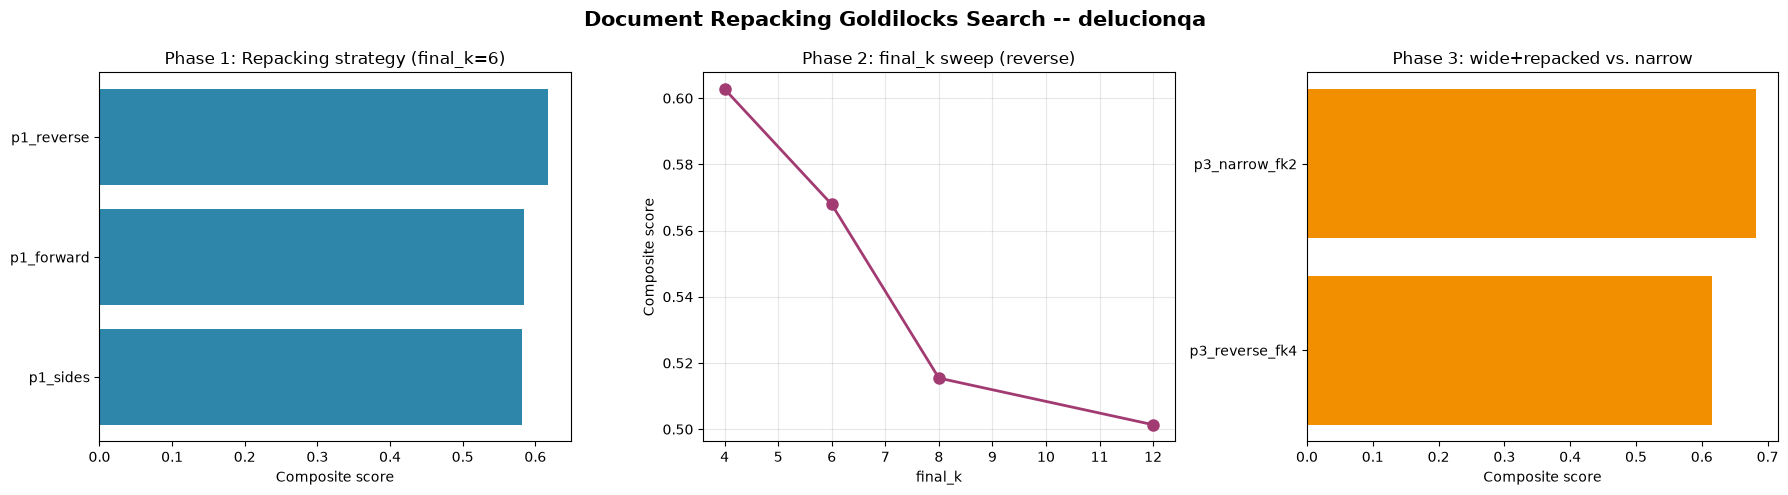

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Document Repacking Goldilocks Search -- {DATASET_NAME}", fontsize=15, fontweight="bold")

p1_plot = phase1_df.dropna(subset=["composite"]).sort_values("composite")
axes[0].barh(p1_plot["config"], p1_plot["composite"], color="#2E86AB")
axes[0].set_xlabel("Composite score")
axes[0].set_title(f"Phase 1: Repacking strategy (final_k={FINAL_K_PHASE1})")

p2_plot = phase2_df.dropna(subset=["composite"]).sort_values("final_k")
axes[1].plot(p2_plot["final_k"], p2_plot["composite"], "o-", color="#A23B72", linewidth=2, markersize=8)
axes[1].set_xlabel("final_k")
axes[1].set_ylabel("Composite score")
axes[1].set_title(f"Phase 2: final_k sweep ({phase1_winner})")
axes[1].grid(True, alpha=0.3)

p3_plot = phase3_df.dropna(subset=["composite"]).sort_values("composite")
axes[2].barh(p3_plot["config"], p3_plot["composite"], color="#F18F01")
axes[2].set_xlabel("Composite score")
axes[2].set_title("Phase 3: wide+repacked vs. narrow")

plt.tight_layout()
plt.show()


## Step 12: Final Recommendation

In [12]:
all_results_df = pd.concat([phase1_df, phase2_df, phase3_df], ignore_index=True)
all_results_df = all_results_df.dropna(subset=["composite"]).sort_values("composite", ascending=False)

print("=" * 100)
print("ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE")
print("=" * 100)
display(all_results_df[[
    "config", "final_k", "n_eval", "n_failed",
    "context_relevance", "utilization", "completeness", "adherence", "composite",
]])

best = all_results_df.iloc[0]
narrow_row = phase3_df[phase3_df["config"] == "p3_narrow_fk2"].iloc[0]

print("\n" + "=" * 100)
print(f"🏆 GOLDILOCKS REPACKING CONFIG: {best['config']}")
print("=" * 100)
print(f"  final_k:            {best['final_k']:.0f}")
print(f"  Context Relevance:  {best['context_relevance']:.4f}")
print(f"  Utilization:        {best['utilization']:.4f}")
print(f"  Completeness:       {best['completeness']:.4f}")
print(f"  Adherence:          {best['adherence']:.4f}")
print(f"  Composite:          {best['composite']:.4f}")
print(f"  Eval sample:        {best['n_eval']}/{EVAL_SAMPLE_SIZE} succeeded (failed: {best['n_failed']})")
if narrow_row["composite"] is not None and best["config"] != "p3_narrow_fk2":
    delta = best["composite"] - narrow_row["composite"]
    print(f"  vs. narrow final_k=2 (no repacking needed): {delta:+.4f} composite "
          f"({'wide+repacked wins' if delta > 0 else 'narrow final_k=2 still wins'})")
print("=" * 100)


ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE


,config,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
7,p3_narrow_fk2,2,20,0,0.602360,0.388615,0.653335,0.90,0.682119
0,p1_reverse,6,20,0,0.440575,0.209625,0.548710,1.00,0.617951
8,p3_reverse_fk4,4,20,0,0.491515,0.226480,0.517400,0.95,0.616112
3,p2_reverse_fk4,4,20,0,0.504995,0.230765,0.509110,0.90,0.602730
1,p1_forward,6,20,0,0.387620,0.164545,0.493530,1.00,0.584378
2,p1_sides,6,20,0,0.370520,0.190170,0.485950,1.00,0.581100
4,p2_reverse_fk6,6,20,0,0.388935,0.192090,0.586345,0.90,0.567892
5,p2_reverse_fk8,8,20,0,0.319490,0.177265,0.530175,0.85,0.515437
6,p2_reverse_fk12,12,20,0,0.219420,0.118120,0.612250,0.90,0.501352



🏆 GOLDILOCKS REPACKING CONFIG: p3_narrow_fk2
  final_k:            2
  Context Relevance:  0.6024
  Utilization:        0.3886
  Completeness:       0.6533
  Adherence:          0.9000
  Composite:          0.6821
  Eval sample:        20/20 succeeded (failed: 0)


### Caveats -- do not treat these exact numbers as final

- **Still a single run on one fixed 20-question sample.** Retrying failed annotations and
  reusing the same question set across every config removes some noise, but this is one
  dataset draw.
- **Chunking, retriever, query transformation, and reranker held constant** at `11`-`14`'s
  winning configs. Whether a different upstream pipeline changes which repacking strategy
  wins (or whether repacking matters at all) is not explored here.
- **`query_llm` runs at temperature 0.7** for the HyDE retrieval string feeding every
  config's candidate pool -- a repeat run could shuffle close results even on the same
  fixed question set.
- **The `sides` implementation here is one reasonable interpretation** (alternating
  head/tail placement by rank) of the paper's description; the paper doesn't specify an
  exact algorithm, so a different implementation could rank differently.
- **The OpenRouter rerank endpoint is a third-party dependency** with its own latency,
  cost, and availability characteristics not modeled by the composite score.
- **Composite score weighting (0.35/0.15/0.15/0.35) is a judgment call**, kept identical to
  `11`-`14` for comparability. The raw per-metric columns are in every results table if you
  want to re-rank by a different weighting or a single metric.
